In [26]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Configuración de rutas
sys.path.append("..")
from models.ridge_model import RidgeModel
from models.random_forest_model import RandomForestModel
from models.xgboost_model import XGBoostModel
from models.lightgbm_model import LightGBMModel
from models.mlp_sklearn_model import MLPModel

from sklearn.preprocessing import StandardScaler # <--- ADICIÓN CLAVE

print("Imports OK")

Imports OK


In [27]:
# ===============================
# 0. Configuración paths y device
# ===============================
os.makedirs('../outputs/plots', exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on: {device}")


Working on: cuda


In [28]:
# ===============================
# 1. Cargar embeddings y labels + SCORE ENERGÉTICO
# ===============================
print("Cargando datos y embeddings...")
df = pd.read_csv('../data/processed_dataset.csv')
embeddings = torch.load('../outputs/embeddings.pt')

Cargando datos y embeddings...


In [29]:
# Convertir embeddings a numpy (480 columnas)
X_emb = embeddings.numpy()

# EXTRAER SCORE ENERGÉTICO (La columna 'mpnn' del CSV)
# Asegúrate de que en tu CSV la columna se llame 'mpnn'
X_score = df['score'].values.reshape(-1, 1)

# CONCATENAR: 480 (ESM2) + 1 (MPNN) = 481 columnas
X = np.hstack([X_emb, X_score])

# Labels
y = df[['PTM', 'IPTM']].values

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Éxito: Matriz final con {X.shape[1]} columnas (480 ESM2 + 1 Score)")

✅ Éxito: Matriz final con 1281 columnas (480 ESM2 + 1 Score)


In [30]:
# ===============================
# DISPLAY DE DISTRIBUCIÓN
# ===============================
print("-" * 30)
print(f"📊 Resumen del Split (80/20) con Feature Engineering:")
print(f"Total de registros: {len(X)}")
print(f"Columnas totales (Features): {X.shape[1]}") # Aquí debería decir 481
print(f"TRAIN (Entrenamiento): {X_train.shape[0]} muestras")
print(f"TEST  (Validación):    {X_test.shape[0]} muestras")
print("-" * 30)

------------------------------
📊 Resumen del Split (80/20) con Feature Engineering:
Total de registros: 45016
Columnas totales (Features): 1281
TRAIN (Entrenamiento): 36012 muestras
TEST  (Validación):    9004 muestras
------------------------------


In [31]:
# ===============================
# 2. Configuración de Modelos
# ===============================
models_to_train = {
    "ridge": RidgeModel(),
    "rf": RandomForestModel(),
    "xgb": XGBoostModel(),
    "lgbm": LightGBMModel(),
    "mlp_sk": MLPModel()
}

results = []

In [32]:
# ===============================
# 3. Loop de entrenamiento y evaluación
# ===============================
for name, model in models_to_train.items():
    print(f"Entrenando {name}...")
    model.fit(X_train, y_train)
    model.save(f"../outputs/model_{name}.pkl")
    
    preds = model.predict(X_test)
    
    # Métricas individuales
    r2_ptm = r2_score(y_test[:, 0], preds[:, 0])
    r2_iptm = r2_score(y_test[:, 1], preds[:, 1])
    rmse_ptm = np.sqrt(mean_squared_error(y_test[:, 0], preds[:, 0]))
    rmse_iptm = np.sqrt(mean_squared_error(y_test[:, 1], preds[:, 1]))
    
    results.append({
        "model": name,
        "R2_PTM": r2_ptm,
        "R2_IPTM": r2_iptm,
        "RMSE_PTM": rmse_ptm,
        "RMSE_IPTM": rmse_iptm
    })

df_results = pd.DataFrame(results)
df_results.to_csv('../outputs/model_metrics.csv', index=False)
display(df_results)

Entrenando ridge...

📈 Entrenando Ridge...
✅ Ridge terminado
⏱ Tiempo: 0.65 seg
💾 Modelo guardado: ../outputs/model_ridge.pkl
🔎 Prediciendo con Ridge...
Entrenando rf...

🌲 Entrenando Random Forest...
Samples: 36012
Features: 1281


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:  1.4min remaining:    9.0s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:  1.6min finished
[Parallel(n_jobs=30)]: Using backend ThreadingBackend with 30 concurrent workers.
[Parallel(n_jobs=30)]: Done   2 out of  30 | elapsed:    0.0s remaining:    0.3s
[Parallel(n_jobs=30)]: Done  30 out of  30 | elapsed:    0.0s finished


✅ Entrenamiento terminado
⏱ Tiempo: 95.55 segundos
💾 Modelo guardado en: ../outputs/model_rf.pkl
🔎 Generando predicciones con Random Forest...
Entrenando xgb...

🚀 Entrenando XGBoost...
✅ XGBoost terminado
⏱ Tiempo: 89.66 seg
💾 Modelo XGBoost guardado en: ../outputs/model_xgb.pkl
Entrenando lgbm...
Training LightGBM model...
LightGBM model saved to ../outputs/model_lgbm.pkl
Entrenando mlp_sk...

🧠 Entrenando MLP (Sklearn)...


/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Iteration 1, loss = 0.00698130
Iteration 2, loss = 0.00451178
Iteration 3, loss = 0.00400928
Iteration 4, loss = 0.00373992
Iteration 5, loss = 0.00370578
Iteration 6, loss = 0.00367559
Iteration 7, loss = 0.00347122
Iteration 8, loss = 0.00358108
Iteration 9, loss = 0.00343983
Iteration 10, loss = 0.00344724
Iteration 11, loss = 0.00333313
Iteration 12, loss = 0.00341142
Iteration 13, loss = 0.00336613
Iteration 14, loss = 0.00323279
Iteration 15, loss = 0.00326103
Iteration 16, loss = 0.00316939
Iteration 17, loss = 0.00328717
Iteration 18, loss = 0.00321390
Iteration 19, loss = 0.00322682
Iteration 20, loss = 0.00316426
Iteration 21, loss = 0.00308561
Iteration 22, loss = 0.00303117
Iteration 23, loss = 0.00323005
Iteration 24, loss = 0.00303596
Iteration 25, loss = 0.00306261
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
✅ MLP terminado
⏱ Tiempo: 118.05 seg
💾 Modelo MLP guardado en: ../outputs/model_mlp_sk.pkl


,model,R2_PTM,R2_IPTM,RMSE_PTM,RMSE_IPTM
0,ridge,0.630156,0.725109,0.025075,0.118755
1,rf,0.838561,0.883217,0.016567,0.077404
2,xgb,0.871540,0.903080,0.014778,0.070514
3,lgbm,0.821829,0.868681,0.017404,0.082080
4,mlp_sk,0.672214,0.792941,0.023606,0.103067


In [8]:
# ===============================
# 4. Visualización de Resultados
# ===============================
def plot_analysis(y_true, y_pred, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # PTM
    sns.scatterplot(x=y_true[:, 0], y=y_pred[:, 0], ax=axes[0], alpha=0.3)
    axes[0].plot([0, 1], [0, 1], '--r')
    axes[0].set_title(f"{model_name} - PTM: Actual vs Pred")
    
    # IPTM
    sns.scatterplot(x=y_true[:, 1], y=y_pred[:, 1], ax=axes[1], alpha=0.3, color='orange')
    axes[1].plot([0, 1], [0, 1], '--r')
    axes[1].set_title(f"{model_name} - IPTM: Actual vs Pred")
    
    plt.tight_layout()
    plt.savefig(f"../outputs/plots/scatter_{model_name}.png")
    plt.show()

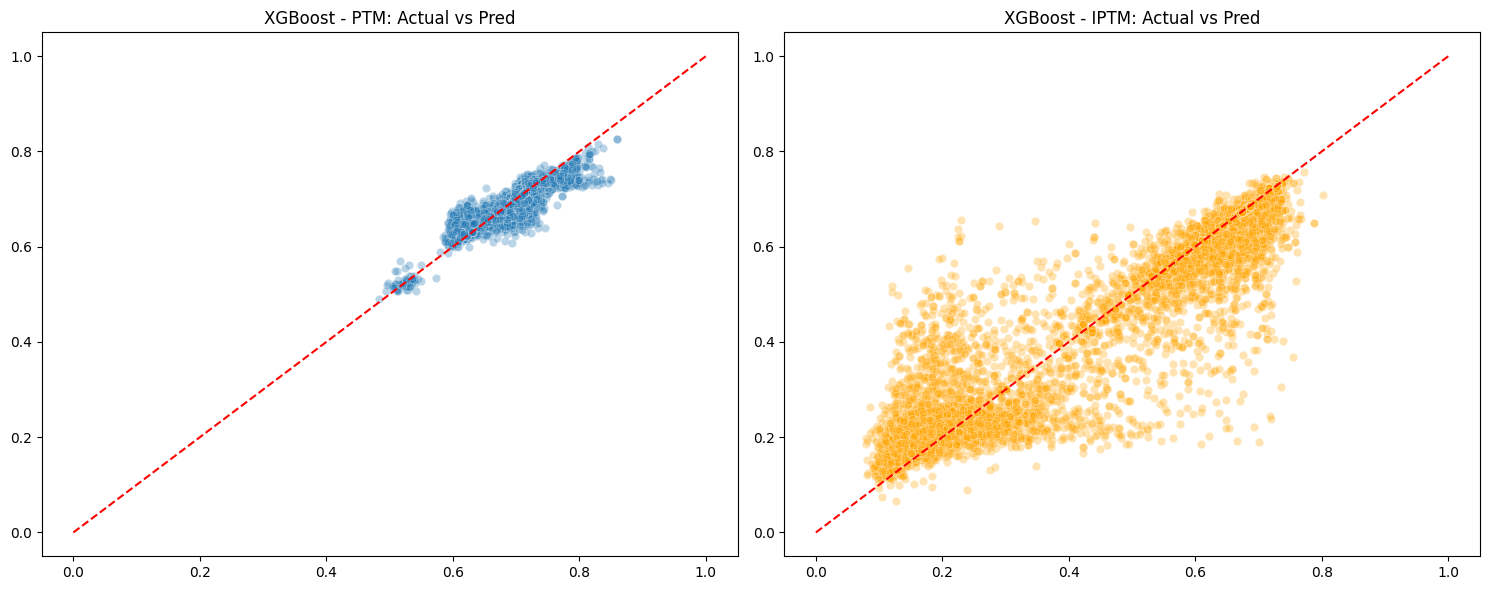

In [12]:
# Ejecutar para los dos mejores candidatos
best_preds_xgb = models_to_train['xgb'].predict(X_test)
plot_analysis(y_test, best_preds_xgb, "XGBoost")

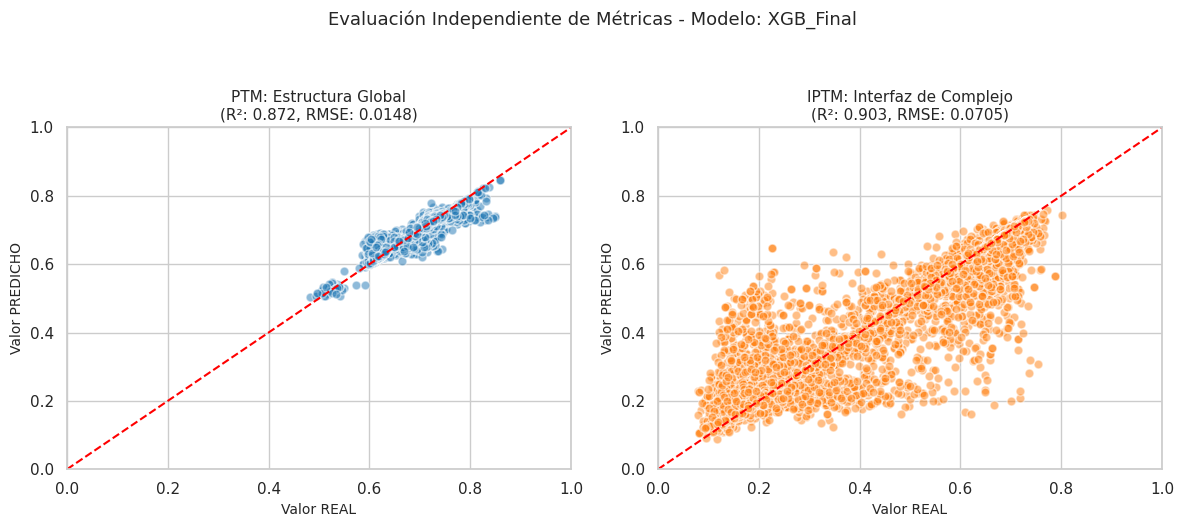

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# Asegura la renderización en el Notebook
%matplotlib inline

def plot_real_vs_pred_separated(y_true, y_pred, model_name="XGBoost_Optimized"):
    """
    Genera dos imágenes separadas (PTM e IPTM) para evaluar la fidelidad 
    del modelo de forma independiente.
    """
    plt.close('all')
    sns.set_theme(style="whitegrid")
    
    # Creamos una figura con dos subgráficos (1 fila, 2 columnas)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # --- GRÁFICA 1: PTM (AZUL) ---
    r2_p = r2_score(y_true[:, 0], y_pred[:, 0])
    rmse_p = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    
    ax1.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5, color='#1f77b4', edgecolor='w', s=40)
    ax1.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1.5)
    ax1.set_title(f"PTM: Estructura Global\n(R²: {r2_p:.3f}, RMSE: {rmse_p:.4f})", fontsize=11)
    ax1.set_xlabel("Valor REAL", fontsize=10)
    ax1.set_ylabel("Valor PREDICHO", fontsize=10)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)

    # --- GRÁFICA 2: IPTM (NARANJA) ---
    r2_i = r2_score(y_true[:, 1], y_pred[:, 1])
    rmse_i = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))
    
    ax2.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5, color='#ff7f0e', edgecolor='w', s=40)
    ax2.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1.5)
    ax2.set_title(f"IPTM: Interfaz de Complejo\n(R²: {r2_i:.3f}, RMSE: {rmse_i:.4f})", fontsize=11)
    ax2.set_xlabel("Valor REAL", fontsize=10)
    ax2.set_ylabel("Valor PREDICHO", fontsize=10)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)

    plt.suptitle(f"Evaluación Independiente de Métricas - Modelo: {model_name}", fontsize=13, y=1.05)
    plt.tight_layout()
    
    # Guardado
    save_path = "../outputs/plots"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, f"separated_metrics_{model_name}.png"), dpi=300, bbox_inches='tight')
    
    plt.show()

# --- EJECUCIÓN ---
if 'xgb' in models_to_train:
    # Obtenemos predicciones
    y_pred_xgb = models_to_train['xgb'].predict(X_test)
    
    # Ejecutamos la nueva visualización separada
    plot_real_vs_pred_separated(y_test, y_pred_xgb, model_name="XGB_Final")
else:
    print("⚠️ Modelo 'xgb' no encontrado en el diccionario.")

/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


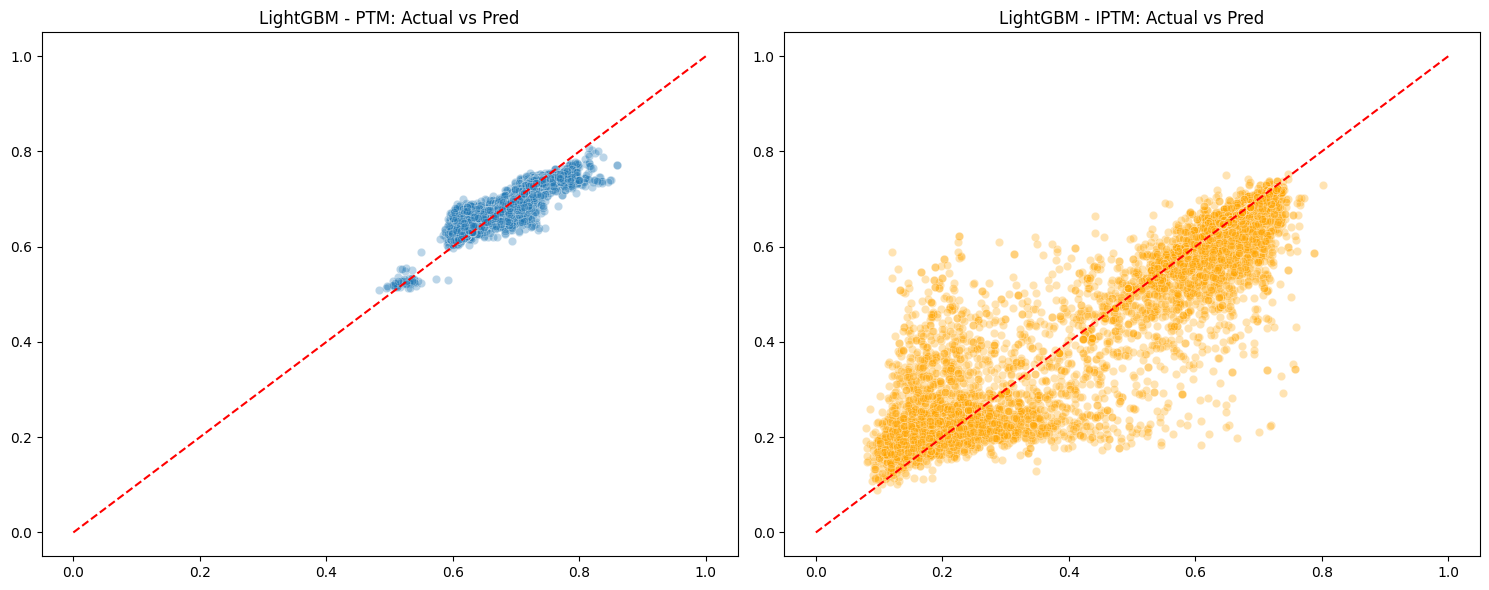

In [10]:
# Si LightGBM resulta ser mejor en tu dataset:
best_preds = models_to_train['lgbm'].predict(X_test)

# Quitamos df_results de aquí para que coincida con la definición de la función
plot_analysis(y_test, best_preds, "LightGBM")